In [2]:
# import the library
import os
import cv2
import sys
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import YouTubeVideo, display, HTML
from base64 import b64encode

%matplotlib inline

# Accessing the Camera

In [3]:
s = 0
if len(sys.argv) > 1:
    s = sys.argv[1]

source = cv2.VideoCapture(s)

win_name = 'Camera Preview'
cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)

while cv2.waitKey(1) != 27: # Escape
    has_frame, frame = source.read()
    if not has_frame:
        break
    cv2.imshow(win_name, frame)

source.release()
cv2.destroyWindow(win_name)

# Read video from source

In [4]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [5]:
URL = r"https://www.dropbox.com/s/p8h7ckeo2dn1jtz/opencv_bootcamp_assets_NB6.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB6.zip")

# Download if assest ZIP does not exists.
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

# Read Video from Source

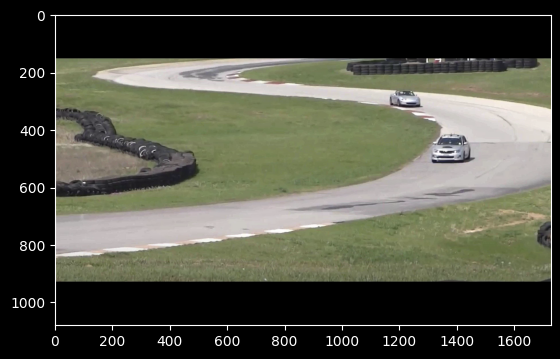

In [6]:
source = 'race_car.mp4'  # source = 0 for webcam

cap = cv2.VideoCapture(source)

if not cap.isOpened():
    print("Error opening video stream or file")

# Read and display one frame
ret, frame = cap.read()
plt.imshow(frame[..., ::-1])

# Display the video file

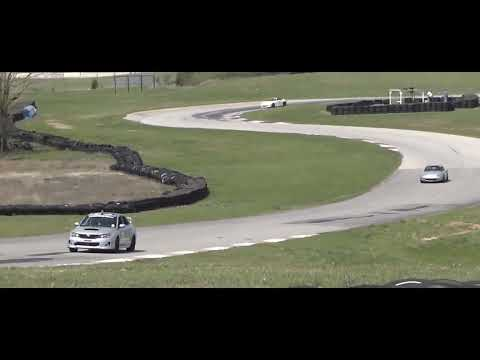

In [8]:
video = YouTubeVideo("RwxVEjv78LQ", width=700, height=438)
display(video)

# Write Video using OpenCV

For writing the video, you need to create a video writer object with the right parameters.

Function Syntax
```python
VideoWriter = cv.VideoWriter(filename, fourcc, fps, frameSize )
```
where, Parameters
+ filename: Name of the output video file.
+ fourcc: 4-character code of codec used to compress the frames. For example, VideoWriter::fourcc('P','I','M','1') is a MPEG-1 codec, VideoWriter::fourcc('M','J','P','G') is a motion-jpeg codec etc. List of codes can be obtained at Video Codecs by FOURCC page. FFMPEG backend with MP4 container natively uses other values as fourcc code: see ObjectType, so you may receive a warning message from OpenCV about fourcc code conversion.
+ fps: Framerate of the created video stream.
+ frameSize: Size of the video frames.

In [ ]:
# Default resolutions of the frame are obtained.
# Convert the resolutions from float to integer.
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

# Define the codec and create VideoWriter object.
out_avi = cv2.VideoWriter("race_car_out.avi", cv2.VideoWriter_fourcc("M", "J", "P", "G"), 10, (frame_width, frame_height))

out_mp4 = cv2.VideoWriter("race_car_out.mp4", cv2.VideoWriter_fourcc(*"XVID"), 10, (frame_width, frame_height))

# Read frames and write to file

# Read until video is completed
while cap.isOpened():
    # Capture frame-by-frame
    ret, frame = cap.read()

    if ret:
        # Write the frame to the output files
        out_avi.write(frame)
        out_mp4.write(frame)

    # Break the loop
    else:
        break

# When everything done, release the VideoCapture and VideoWriter objects
cap.release()
out_avi.release()
out_mp4.release()

